In [1]:
import pandas as pd

# Load the data
train = pd.read_csv('../data/raw/kathmandu_reviews_dataset/split_train.csv')
val   = pd.read_csv('../data/raw/kathmandu_reviews_dataset/split_val.csv')
test  = pd.read_csv('../data/raw/kathmandu_reviews_dataset/split_test.csv')

print("Train shape:", train.shape)
print("Val shape:  ", val.shape)
print("Test shape: ", test.shape)
print("\nSentiment distribution in training data:")
print(train['sentiment_label'].value_counts())

Train shape: (70000, 22)
Val shape:   (15000, 22)
Test shape:  (15000, 22)

Sentiment distribution in training data:
sentiment_label
positive    40600
negative    21000
neutral      8400
Name: count, dtype: int64


In [2]:
# First 5 rows
print("Columns:", train.columns.tolist())
print("\nSample reviews:")
train[['review_id', 'review_text', 'sentiment_label']].head(5)

Columns: ['review_id', 'product_id', 'product_name', 'product_category', 'brand', 'product_price_npr', 'seller_name', 'delivery_partner', 'reviewer_location', 'payment_method', 'review_date', 'review_text', 'rating', 'sentiment_label', 'verified_purchase', 'helpful_count', 'review_length_chars', 'review_length_tokens', 'english_token_ratio', 'nepali_token_ratio', 'language_dominance', 'has_emoji']

Sample reviews:


,review_id,review_text,sentiment_label
0,R050323,Best purchase of the year ho yo! Door step del...,positive
1,R073637,"Wow, ekdam ramro product cha! Battery backup r...",positive
2,R016327,"Imported jasto feel auncha, super product. Fit...",positive
3,R011633,"Wow, ekdam ramro product cha! Aru saamaan pani...",positive
4,R092362,Best purchase of the year ho yo! Free shipping...,positive


In [3]:
# Missing values
print("Missing values in training data:")
print(train.isnull().sum())

Missing values in training data:
review_id               0
product_id              0
product_name            0
product_category        0
brand                   0
product_price_npr       0
seller_name             0
delivery_partner        0
reviewer_location       0
payment_method          0
review_date             0
review_text             0
rating                  0
sentiment_label         0
verified_purchase       0
helpful_count           0
review_length_chars     0
review_length_tokens    0
english_token_ratio     0
nepali_token_ratio      0
language_dominance      0
has_emoji               0
dtype: int64


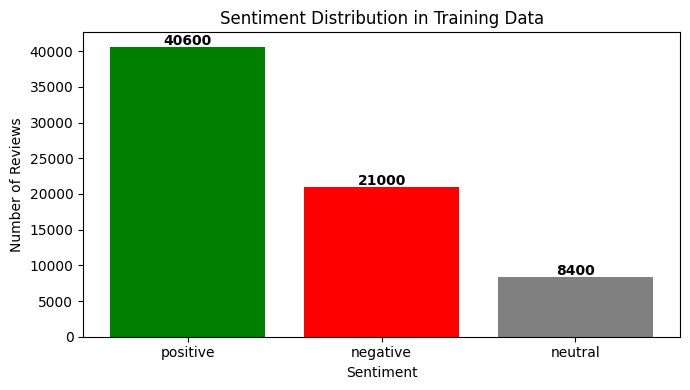

Chart saved to results folder!


In [4]:
import matplotlib.pyplot as plt

# Count each sentiment
counts = train['sentiment_label'].value_counts()

# Plot
plt.figure(figsize=(7, 4))
plt.bar(counts.index, counts.values, color=['green', 'red', 'gray'])
plt.title('Sentiment Distribution in Training Data')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')
for i, v in enumerate(counts.values):
    plt.text(i, v + 200, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('../results/sentiment_distribution.png', dpi=150)
plt.show()
print("Chart saved to results folder!")

Review length (in words) statistics:
count    70000.00
mean        20.80
std          9.34
min          1.00
25%         15.00
50%         22.00
75%         27.00
max         55.00
Name: review_length_tokens, dtype: float64


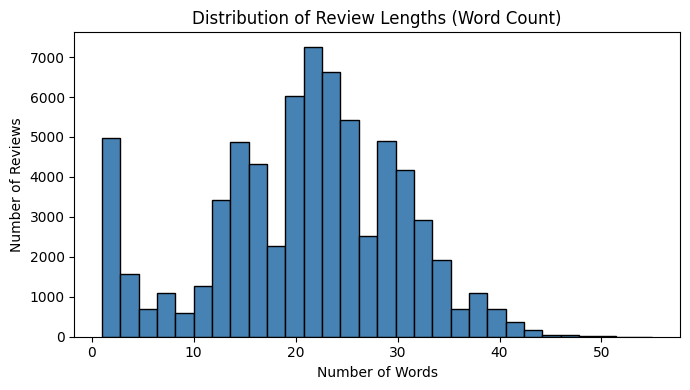

Chart saved!


In [5]:
# Review length stats
print("Review length (in words) statistics:")
print(train['review_length_tokens'].describe().round(2))

# Plot distribution
plt.figure(figsize=(7, 4))
plt.hist(train['review_length_tokens'], bins=30, color='steelblue', edgecolor='black')
plt.title('Distribution of Review Lengths (Word Count)')
plt.xlabel('Number of Words')
plt.ylabel('Number of Reviews')
plt.tight_layout()
plt.savefig('../results/review_length_distribution.png', dpi=150)
plt.show()
print("Chart saved!")

Language dominance breakdown:
language_dominance
Nepali-dominant     35974
Balanced            20507
English-dominant    13519
Name: count, dtype: int64

Percentages:
language_dominance
Nepali-dominant     51.39
Balanced            29.30
English-dominant    19.31
Name: count, dtype: float64


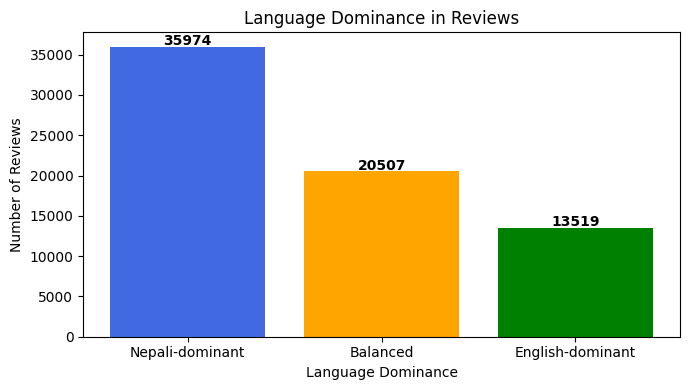

Chart saved!


In [6]:
# Language dominance breakdown
lang_counts = train['language_dominance'].value_counts()
print("Language dominance breakdown:")
print(lang_counts)
print(f"\nPercentages:")
print((lang_counts / len(train) * 100).round(2))

# Plot
plt.figure(figsize=(7, 4))
plt.bar(lang_counts.index, lang_counts.values, color=['royalblue', 'orange', 'green'])
plt.title('Language Dominance in Reviews')
plt.xlabel('Language Dominance')
plt.ylabel('Number of Reviews')
for i, v in enumerate(lang_counts.values):
    plt.text(i, v + 200, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('../results/language_dominance.png', dpi=150)
plt.show()
print("Chart saved!")

In [7]:
# Show 2 sample reviews from each sentiment class
for sentiment in ['positive', 'negative', 'neutral']:
    print(f"\n--- {sentiment.upper()} EXAMPLES ---")
    samples = train[train['sentiment_label'] == sentiment]['review_text'].sample(2, random_state=42)
    for i, review in enumerate(samples, 1):
        print(f"{i}. {review}")


--- POSITIVE EXAMPLES ---
1. First time order gareko, but ekdam impressed chu. Battery backup ramro cha, full din chal cha. Awesome product, awesome service. Maja aayo. Outer box opened thiyo arrival ma, tampered jasto laagyo.
2. Order garna naparekai bhayena, perfect samaan. Order gareko 2 din mai delivery bhayo, super fast. Sabai lai recommend gareko chu yo seller bata kinna.

--- NEGATIVE EXAMPLES ---
1. Order ko status update pani didaina, kati waste service. User experience naramro cha, paisa khera gayo. Warranty claim ma kura suniyena, bekar policies. 👎
2. Worst!

--- NEUTRAL EXAMPLES ---
1. Average banaune samaan ho, hotai kasto kasto kura chaina. Courier le rough handle gareko hola jasto, but item safe ayo.
2. Yo price range ma yestai paine ho jasto laagcha. Standard packaging, no issues, no extras.
